## Analysis

In [3]:
import os
import json
import numpy as np

def read_val_scores(logs_path):
    val_scores_dir = os.path.join(logs_path, "scores", "val")
    scores_by_step = {}
    for file in os.listdir(val_scores_dir):
        step = int(file.split("_")[0])
        scores_for_step = []
        with open(os.path.join(val_scores_dir, file), "r") as f:
            file_content = f.read()
            for line in file_content.split('\n'):
                if line.strip():  # Skip empty lines
                    line_data = json.loads(line)
                    datapoint_id = int(line_data['env_id'])
                    score = line_data['score']
                    # Extend list if needed
                    while len(scores_for_step) <= datapoint_id:
                        scores_for_step.append(False)
                    scores_for_step[datapoint_id] = bool(score)
        scores_by_step[step] = np.array(scores_for_step)
    return scores_by_step

In [4]:
from matplotlib import pyplot as plt
import numpy as np

def plot_val_scores(val_scores_dict, min_step=None, max_step=None, alpha=1.0):
    """
    Plot validation scores for different agents.

    Args:
        val_scores_dict: Dictionary mapping agent names to dictionaries mapping steps to validation scores
        min_step: minimum step to include in the plot (optional)
        max_step: maximum step to include in the plot (optional)
        alpha: smoothing factor for exponential moving average (optional)
    """
    # Define a larger color palette
    colors = ['#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#1f77b4', 
              '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
              '#1a55FF', '#ff5733', '#33ff57', '#5733ff', '#ff33f5']

    # --- Main Average Accuracy Plot ---
    fig, ax = plt.subplots(figsize=(10, 8))

    for i, (agent_name, scores_by_step) in enumerate(val_scores_dict.items()):
        color = colors[i % len(colors)]  # Cycle through colors

        # Get sorted steps
        steps = sorted(scores_by_step.keys())

        # Filter steps based on min_step and max_step
        if min_step is not None:
            steps = [s for s in steps if s >= min_step]
        if max_step is not None:
            steps = [s for s in steps if s <= max_step]

        # Calculate average scores
        avg_scores = [np.mean(scores_by_step[step]) for step in steps]

        # Calculate smoothed average scores
        smoothed_avg = []
        for j in range(len(avg_scores)):
            if j == 0:
                smoothed_avg.append(avg_scores[j])
            else:
                smoothed_avg.append(alpha * avg_scores[j] + (1 - alpha) * smoothed_avg[j-1])

        # Plot average scores
        ax.plot(steps, avg_scores, color=color, marker='o', linewidth=2, markersize=6, alpha=0.3)
        ax.plot(steps, smoothed_avg, color=color, marker='o', label=f'{agent_name}', linewidth=3, markersize=8, alpha=1.0)

    ax.set_xlabel('Num seen problems')
    ax.set_ylabel('Score')
    ax.set_title('Average Validation Scores Over Num Seen Problems')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    leg = ax.legend(loc='lower center', ncol=2, frameon=True)
    plt.show()

    # --- "Remembering" Accuracy Plot (first 20 problems) ---
    fig_rem, ax_rem = plt.subplots(figsize=(10, 6))
    for i, (agent_name, scores_by_step) in enumerate(val_scores_dict.items()):
        color = colors[i % len(colors)]
        steps = sorted(scores_by_step.keys())
        if min_step is not None:
            steps = [s for s in steps if s >= min_step]
        if max_step is not None:
            steps = [s for s in steps if s <= max_step]
        remembering_scores = []
        for step in steps:
            arr = scores_by_step[step]
            remembering_scores.append(np.mean(arr[:20]) if len(arr) >= 20 else np.nan)
        smoothed_rem = []
        for j in range(len(remembering_scores)):
            if j == 0:
                smoothed_rem.append(remembering_scores[j])
            else:
                smoothed_rem.append(alpha * remembering_scores[j] + (1 - alpha) * smoothed_rem[j-1])
        ax_rem.plot(steps, remembering_scores, color=color, marker='o', linewidth=2, markersize=6, alpha=0.3)
        ax_rem.plot(steps, smoothed_rem, color=color, marker='o', label=f'{agent_name}', linewidth=3, markersize=8, alpha=1.0)
    ax_rem.set_xlabel('Num seen problems')
    ax_rem.set_ylabel('Score on first 20 problems')
    ax_rem.set_title('Remembering Accuracy (First 20 Problems) Over Num Seen Problems')
    ax_rem.grid(True, alpha=0.3)
    plt.tight_layout()
    leg_rem = ax_rem.legend(loc='lower center', ncol=2, frameon=True)
    plt.show()

    # --- "ICL" Accuracy Plot (second 20 problems) ---
    fig_icl, ax_icl = plt.subplots(figsize=(10, 6))
    for i, (agent_name, scores_by_step) in enumerate(val_scores_dict.items()):
        color = colors[i % len(colors)]
        steps = sorted(scores_by_step.keys())
        if min_step is not None:
            steps = [s for s in steps if s >= min_step]
        if max_step is not None:
            steps = [s for s in steps if s <= max_step]
        icl_scores = []
        for step in steps:
            arr = scores_by_step[step]
            # Only take the next 20 after the first 20, so indices 20:40
            if len(arr) >= 40:
                icl_scores.append(np.mean(arr[20:40]))
            elif len(arr) > 20:
                icl_scores.append(np.mean(arr[20:]))
            else:
                icl_scores.append(np.nan)
        smoothed_icl = []
        for j in range(len(icl_scores)):
            if j == 0:
                smoothed_icl.append(icl_scores[j])
            else:
                smoothed_icl.append(alpha * icl_scores[j] + (1 - alpha) * smoothed_icl[j-1])
        ax_icl.plot(steps, icl_scores, color=color, marker='o', linewidth=2, markersize=6, alpha=0.3)
        ax_icl.plot(steps, smoothed_icl, color=color, marker='o', label=f'{agent_name}', linewidth=3, markersize=8, alpha=1.0)
    ax_icl.set_xlabel('Num seen problems')
    ax_icl.set_ylabel('Score on ICL (second 20) problems')
    ax_icl.set_title('ICL Accuracy (Second 20 Problems) Over Num Seen Problems')
    ax_icl.grid(True, alpha=0.3)
    plt.tight_layout()
    leg_icl = ax_icl.legend(loc='lower center', ncol=2, frameon=True)
    plt.show()



## Easy cities analysis

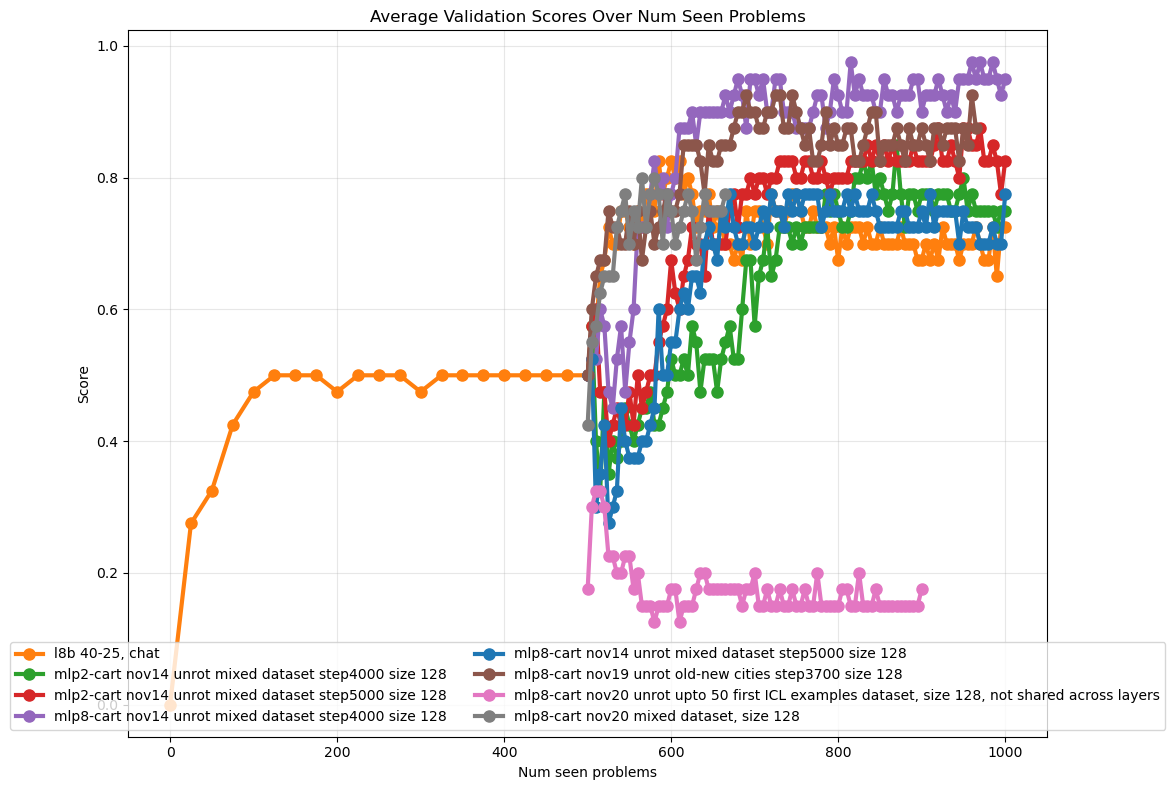

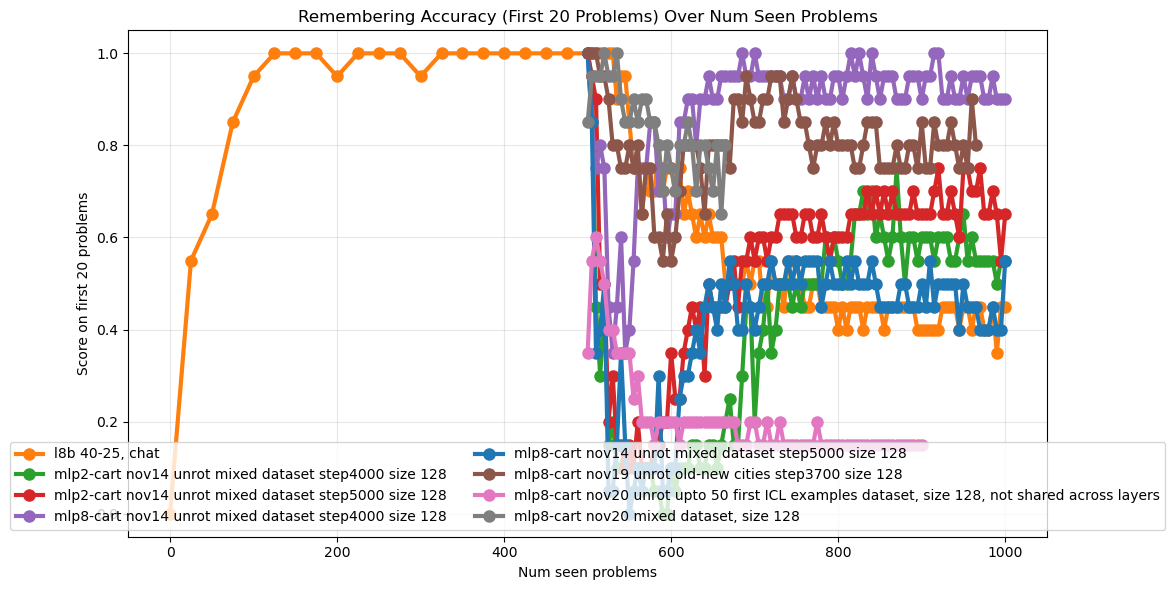

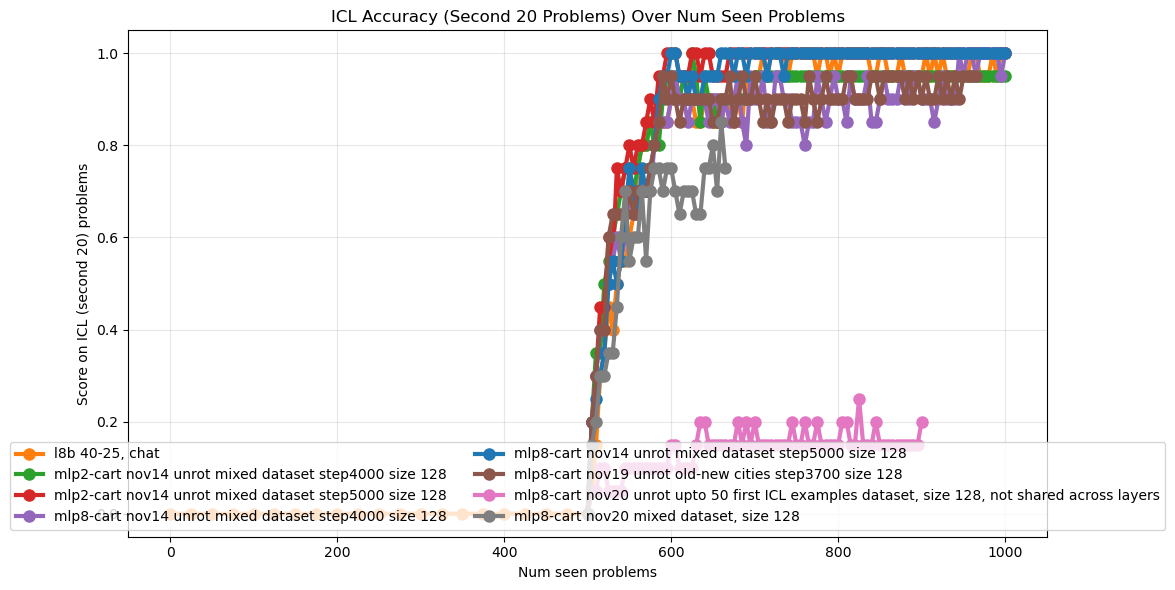

In [7]:
plot_val_scores({

    "l8b 40-25, chat": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_non_collapsed_only_boxed/20251103_101129/"),
                                             **read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_non_collapsed_only_boxed/20251103_181024")},
    # "cartridge nov4_chatboxed-cache-step600": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_cartridge_nov4_chatboxed-cache-step600/20251105_000849")},
    # "cartridge nov6_chatboxed_mixed_dataset-cache-step200": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_cartridge_nov6_chatboxed_mixed_dataset-cache-step200/20251114_211809")},
    # "cartridge nov6_chatboxed_mixed_dataset-cache-step300": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_cartridge_nov6_chatboxed_mixed_dataset-cache-step300/20251114_212108")},
    # "cartridge nov6_chatboxed_mixed_dataset-cache-step400": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_cartridge_nov6_chatboxed_mixed_dataset-cache-step400/20251107_115242")},
    # "cartridge nov6_chatboxed_mixed_dataset-cache-step500": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_cartridge_nov6_chatboxed_mixed_dataset-cache-step500/20251107_123708")},
    # "cartridge nov12 unrot first half cities step200 offset 0": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_cartridge_nov12_chatboxed_first_half_cities_with_unrot_queries-cache-step200_offset_0/20251113_235636")},
    # "cartridge nov12 unrot mixed dataset step200 offset 0": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_cartridge_nov12_chatboxed_mixed_dataset_with_unrot_queries-cache-step200_offset_0/20251114_004025")},
    # "cartridge nov12 unrot mixed dataset step300 offset 0": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_cartridge_nov12_chatboxed_mixed_dataset_with_unrot_queries-cache-step300_offset_0/20251113_235416")},
    # "cartridge nov12 unrot mixed dataset step500 offset 0": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_cartridge_nov12_chatboxed_mixed_dataset_with_unrot_queries-cache-step500_offset_0/20251113_203228")},
    # "cartridge nov12 unrot mixed dataset step800 offset 0": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_cartridge_nov12_chatboxed_mixed_dataset_with_unrot_queries-cache-step800_offset_0/20251113_231756")},   
    # "cartrdige nov13 unrot mixed dataset step100 size 128": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_cartridge_nov13_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors-cache-step100/20251114_022258")},
    # "cartrdige nov13 unrot mixed dataset step200 size 128": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_cartridge_nov13_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors-cache-step200/20251114_044120")},
    # "cartridge nov13 unrot mixed dataset step100 size 1024": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_cartridge_nov13_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors_1024_tokens_cartridge-cache-step100/20251114_022338")},
    # "cartridge nov13 unrot mixed dataset step200 size 1024": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_cartridge_nov13_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors_1024_tokens_cartridge-cache-step200/20251114_043833")},
    # "cartridge nov13 unrot mixed dataset step100 size 8192": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_cartridge_nov13_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors_8192_tokens_cartridge-cache-step100/20251114_180619")},
    # "cartridge nov13 unrot mixed dataset step200 size 8192": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_cartridge_nov13_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors_8192_tokens_cartridge-cache-step200/20251114_180727")},
    # "cartridge nov14   rot mixed dataset step100 size 8192": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov14_chatboxed_mixed_dataset_with_rot_queries_eval_with_up_to_50_distractors_8192_tokens_cartridge-cache-step100/20251116_210654")},
    # "cartridge nov14   rot mixed dataset step200 size 8192": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov14_chatboxed_mixed_dataset_with_rot_queries_eval_with_up_to_50_distractors_8192_tokens_cartridge-cache-step200/20251116_210841")},
    # "mlp2-cart nov14 unrot mixed dataset step700 size 128": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov14_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors_mlp_residual_2-cache-step700/20251116_212401")},
    # "mlp2-cart nov14 unrot mixed dataset step1500 size 128": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov14_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors_mlp_residual_2-cache-step1500/20251116_235631")},
    # "mlp2-cart nov14 unrot mixed dataset step1500 size 128": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov14_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors_mlp_residual_2-cache-step1500/20251116_235631")},
    # "mlp2-cart nov14 unrot mixed dataset step3000 size 128 (1)": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov14_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors_mlp_residual_2-cache-step3000/20251117_021550")},
    # "mlp2-cart nov14 unrot mixed dataset step3000 size 128 (2)": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov14_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors_mlp_residual_2-cache-step3000/20251117_021608")},
    "mlp2-cart nov14 unrot mixed dataset step4000 size 128": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov14_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors_mlp_residual_2-cache-step4000/20251117_171425")},
    "mlp2-cart nov14 unrot mixed dataset step5000 size 128": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov14_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors_mlp_residual_2-cache-step5000/20251117_182204")},
    # "mlp8-cart nov14 unrot mixed dataset step700 size 128": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov14_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors_mlp_residual_8-cache-step700/20251116_212336")},
    # "mlp8-cart nov14 unrot mixed dataset step1700 size 128": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov14_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors_mlp_residual_8-cache-step1700/20251116_235754")},
    # "mlp8-cart nov14 unrot mixed dataset step3000 size 128": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov14_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors_mlp_residual_8-cache-step3000/20251117_051204")},
    "mlp8-cart nov14 unrot mixed dataset step4000 size 128": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov14_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors_mlp_residual_8-cache-step4000/20251117_171453")},
    "mlp8-cart nov14 unrot mixed dataset step5000 size 128": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov14_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors_mlp_residual_8-cache-step5000/20251117_182518")},
    # "mlp2-cart nov14 unrot mixed dataset step2000 size 1024": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov14_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors_mlp_residual_2_cartridge_1024-cache-step2000/20251117_225528")},
    # "mlp8-cart nov14 unrot mixed dataset step2000 size 8192": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov14_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors_mlp_residual_8_cartridge_8192-cache-step2000/20251117_225304")},
    # "mlp8-cart nov14 unrot mixed dataset step3000 size 8192": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov14_chatboxed_mixed_dataset_with_unrot_queries_eval_with_up_to_50_distractors_mlp_residual_8_cartridge_8192-cache-step3000/20251118_022707")},
    # "mlp2-cart nov17 unrot old cities step1000 size 128": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov17_chatboxed_with_up_to_50_distractors_dataset_with_unrot_queries_mlp_residual_2-cache-step1000/20251118_021954")},
    # "mlp2-cart nov17 unrot old cities step1500 size 128": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov17_chatboxed_with_up_to_50_distractors_dataset_with_unrot_queries_mlp_residual_2-cache-step1500/20251118_022056")},
    "mlp8-cart nov19 unrot old-new cities step3700 size 128": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov19_dataset_15000_old_cities_2500_new_cities_unrot_queries_mlp_residual_8_toka_lr_5e-3_attempt_1-cache-step3700/20251121_001224")},
    "mlp8-cart nov20 unrot upto 50 first ICL examples dataset, size 128, not shared across layers": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov20_upto_50_first_ICL_examples_dataset_unrot_queries_mlp_residual_8_toka_lr_5e-4_not_shared-cache-step500/20251121_004520")},
    "mlp8-cart nov20 mixed dataset, size 128": {**read_val_scores("/data/stalaei/logs/continual_learning/outputs/stalaei_cities_easy/history_agent/easy_synth_cities_40_25_l8b_nov20_mixed_dataset_unrot_queries_mlp_residual_8_toka_attempt_1-cache-step1200/20251121_021657")}
    }, alpha=1.0)

## Data distribution analysis

In [13]:
import os
import json
import re
from collections import Counter
import matplotlib.pyplot as plt

from tqdm import tqdm  # Add tqdm for progress bars

box_pattern = re.compile(r"\\boxed\{(.*?)\}")

def extract_boxed(text):
    """Extract the first \boxed{...} block in text, or None if not found."""
    match = box_pattern.search(text)
    if match:
        return match.group(1).strip()
    return None

def get_boxed_from_dir(data_dir, use_tqdm=True):
    """
    Given a directory, finds all boxed outputs in synthetic*.json or .jsonl files.
    Returns a list of boxed outputs.
    """
    all_boxed = []
    fnames = [fname for fname in os.listdir(data_dir) if fname.startswith('synthetic')]
    progress_iter = tqdm(fnames, desc=f"Reading files in {data_dir}") if use_tqdm else fnames
    for fname in progress_iter:
        fpath = os.path.join(data_dir, fname)
        try:
            with open(fpath, 'r') as f:
                content = f.read().strip()
                # handle both .json and .jsonl
                if fname.endswith('.jsonl'):
                    for line in content.splitlines():
                        try:
                            entry = json.loads(line)
                            outmsg = entry.get("output_message", "")
                            boxed = extract_boxed(outmsg)
                            if boxed:
                                all_boxed.append(boxed)
                        except Exception:
                            continue
                elif fname.endswith('.json'):
                    data = json.loads(content)
                    if isinstance(data, list):
                        for entry in data:
                            outmsg = entry.get("output_message", "")
                            boxed = extract_boxed(outmsg)
                            if boxed:
                                all_boxed.append(boxed)
                    elif isinstance(data, dict):
                        outmsg = data.get("output_message", "")
                        boxed = extract_boxed(outmsg)
                        if boxed:
                            all_boxed.append(boxed)
        except Exception as e:
            print(f"Error processing {fname}: {e}")
    return all_boxed

def plot_boxed_histogram_for_datasets(dataset_dirs):
    """
    dataset_dirs: dict mapping {dataset_name: data_dir}
    Plots a histogram of boxed outputs for each dataset directory.
    """
    n_sets = len(dataset_dirs)
    fig, axes = plt.subplots(n_sets, 1, figsize=(12, 6 * n_sets), squeeze=False)
    axes = axes.flatten()
    for i, (name, dir_path) in enumerate(dataset_dirs.items()):
        boxed = get_boxed_from_dir(dir_path)
        box_counts = Counter(boxed)
        ax = axes[i]
        ax.bar(box_counts.keys(), box_counts.values(), color='skyblue')
        ax.set_xlabel("Boxed Output")
        ax.set_ylabel("Count")
        ax.set_title(f"Histogram of Boxed Outputs: {name}")
        ax.tick_params(axis='x', labelrotation=75)
    plt.tight_layout()
    plt.show()

# # Example usage:
# datasets = {
#     "Synthetic Cities Easy (same experiences (shuffled) in memory)": "/scratch/m000122/stalaei/logs/continual_learning/data/cities_easy_synthetic_gen_l8b_20000_with_subsample_and_same_experiences_and_shuffle",
#     "Synthetic Cities Easy (original experiences)": "/scratch/m000122/stalaei/logs/continual_learning/data/cities_easy_synthetic_gen_l8b_20000_with_subsample_and_original_experiences"
# }
# plot_boxed_histogram_for_datasets(datasets)


Reading files in /projects/bfsg/stalaei/logs/continual_learning/data/cities_easy_synthetic_gen_l8b_non_collapsed_boxed_only_20000_with_subsample_and_original_experiences:   0%|          | 0/1050 [00:00<?, ?it/s]

Reading files in /projects/bfsg/stalaei/logs/continual_learning/data/cities_easy_synthetic_gen_l8b_non_collapsed_boxed_only_20000_with_subsample_and_original_experiences: 100%|██████████| 1050/1050 [00:02<00:00, 524.01it/s]


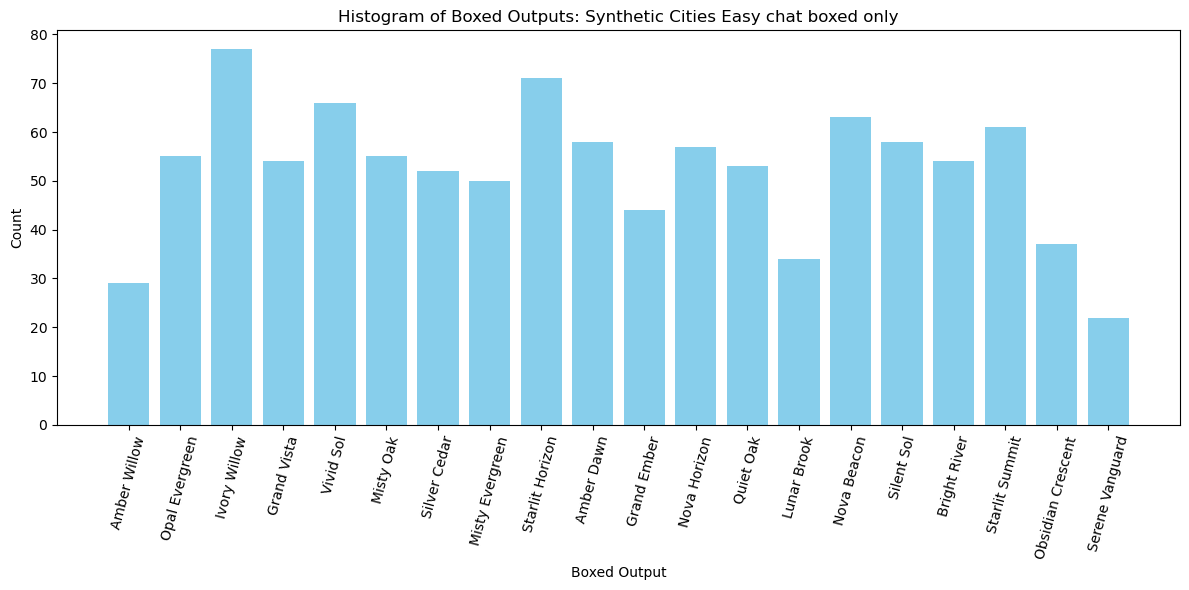

In [14]:
datasets = {
    "Synthetic Cities Easy chat boxed only": "/projects/bfsg/stalaei/logs/continual_learning/data/cities_easy_synthetic_gen_l8b_non_collapsed_boxed_only_20000_with_subsample_and_original_experiences",

}
plot_boxed_histogram_for_datasets(datasets)

## Filtering out none output ids

In [ ]:
# import json
# import os
# from tqdm import tqdm

# jsonl_path = "/projects/bfsg/stalaei/logs/continual_learning/data/cities_easy_synthetic_gen_l8b_non_collapsed_boxed_only_20000_with_subsample_and_original_experiences/dataset.jsonl"

# filtered_rows = []
# total_rows = 0
# none_output_rows = 0

# # Pass 1: Count total for progress bar
# with open(jsonl_path, "r") as f:
#     for _ in f:
#         total_rows += 1

# with open(jsonl_path, "r") as f:
#     for line in tqdm(f, total=total_rows, desc="Filtering"):
#         row = json.loads(line)
#         # Accept if output_ids is present, not None, and not empty
#         if "output_ids" in row and row["output_ids"] is not None:
#             filtered_rows.append(row)
#         else:
#             none_output_rows += 1

# print(f"Original rows: {total_rows}")
# print(f"Rows with None/empty output_ids: {none_output_rows}")
# print(f"Rows kept: {len(filtered_rows)}")

# # Overwrite the file with filtered rows
# with open(jsonl_path, "w") as f:
#     for row in tqdm(filtered_rows, desc="Writing filtered rows"):
#         f.write(json.dumps(row, ensure_ascii=False) + "\n")

# print(f"Filtered dataset written to {jsonl_path}")


Filtering: 100%|██████████| 20000/20000 [00:18<00:00, 1068.33it/s]


Original rows: 20000
Rows with None/empty output_ids: 426
Rows kept: 19574
Filtered dataset written to /projects/bfsg/stalaei/logs/continual_learning/data/cities_easy_synthetic_gen_l8b_non_collapsed_boxed_only_20000_with_subsample_and_original_experiences/dataset.jsonl


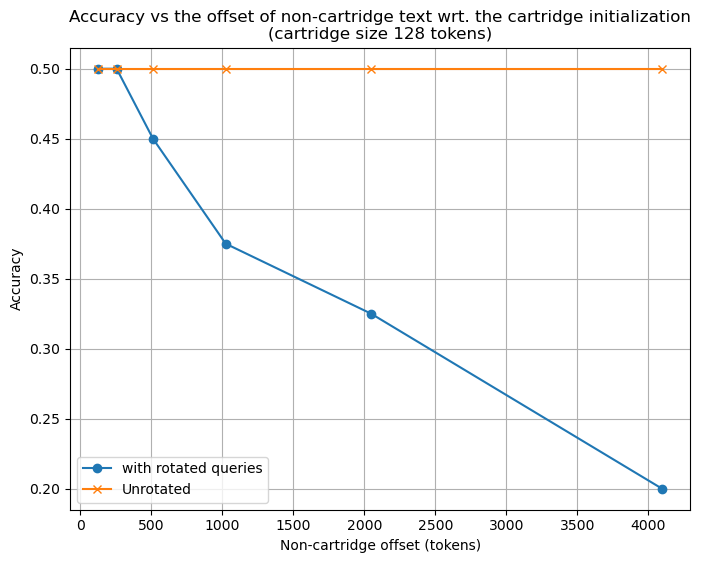

In [12]:
import matplotlib.pyplot as plt

rotated_queries = [ # (offset, accuracy)
    (128, 0.5),
    (256, 0.5),
    (512, 18/40),
    (1024, 15/40),
    (2048, 13/40),
    (4096, 8/40),
]

unrotated_queries = [
    (128, 0.5),
    (256, 0.5),
    (512, 0.5),
    (1024, 0.5),
    (2048, 0.5),
    (4096, 0.5),
]

# Prepare data for plotting
rotated_offsets, rotated_accuracies = zip(*rotated_queries)
unrotated_offsets, unrotated_accuracies = zip(*unrotated_queries)

plt.figure(figsize=(8, 6))
plt.plot(rotated_offsets, rotated_accuracies, c='tab:blue', marker='o', linestyle='-', label='with rotated queries')      # connect dots for rotated
plt.plot(unrotated_offsets, unrotated_accuracies, c='tab:orange', marker='x', linestyle='-', label='Unrotated')  # connect dots for unrotated

plt.title("Accuracy vs the offset of non-cartridge text wrt. the cartridge initialization\n(cartridge size 128 tokens)")
plt.xlabel("Non-cartridge offset (tokens)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()